In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('usa-house-data.csv')

print('Data shape:', data.shape)
data.head()

Data shape: (4140, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-09 00:00:00,376000.0,3.0,2.00,1340,1384,3.0,0,0,3,1340,0,2008,0,9245-9249 Fremont Ave N,Seattle,WA 98103,USA
1,2014-05-09 00:00:00,800000.0,4.0,3.25,3540,159430,2.0,0,0,3,3540,0,2007,0,33001 NE 24th St,Carnation,WA 98014,USA
2,2014-05-09 00:00:00,2238888.0,5.0,6.50,7270,130017,2.0,0,0,3,6420,850,2010,0,7070 270th Pl SE,Issaquah,WA 98029,USA
3,2014-05-09 00:00:00,324000.0,3.0,2.25,998,904,2.0,0,0,3,798,200,2007,0,820 NW 95th St,Seattle,WA 98117,USA
4,2014-05-10 00:00:00,549900.0,5.0,2.75,3060,7015,1.0,0,0,5,1600,1460,1979,0,10834 31st Ave SW,Seattle,WA 98146,USA


R² Score: 0.067
MedAE:   56,336
R² (minus top outlier): 0.645


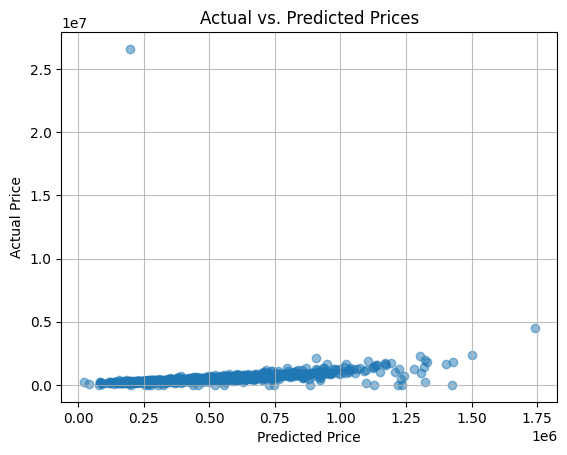

In [2]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import median_absolute_error, r2_score

X = data.drop(['price', 'date', 'street'], axis=1)
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

lb, ub = data['price'].quantile(0.02), data['price'].quantile(0.98)
mask = (y_train >= lb) & (y_train <= ub)
X_train, y_train = X_train[mask], y_train[mask]

numeric_transformer = make_pipeline(StandardScaler())
categorical_transformer = make_pipeline(OneHotEncoder(handle_unknown='ignore'))

cat = X.select_dtypes(include=['object', 'category']).columns.tolist()
num = np.setdiff1d(X.columns, cat)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num),
        ('cat', categorical_transformer, cat)
    ]
)

pipe = make_pipeline(preprocessor, Ridge())
pipe.fit(X_train, y_train)

predictions = pipe.predict(X_test)

print(f"R² Score: {r2_score(y_test, predictions):.3f}")
print(f"MedAE:   {median_absolute_error(y_test, predictions):,.0f}")

err = np.abs(predictions - y_test)
keep = err < np.sort(err)[-1:].min()
print(f"R² (minus top outlier): {r2_score(y_test[keep], predictions[keep]):.3f}")

plt.scatter(predictions, y_test, alpha=0.5)
plt.xlabel('Predicted Price')
plt.ylabel('Actual Price')
plt.title('Actual vs. Predicted Prices')
plt.grid(True, alpha=0.8)

In [3]:
feature_names = pipe[:-1].get_feature_names_out()
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': pipe[-1].coef_
}).sort_values(by="Coefficient", ascending=False)

top = 5
print(f'Top {top} coef:\n{coef_df.head(top)}\nWorst {top} coef:\n{coef_df.tail(top)}')

Top 5 coef:
                    Feature    Coefficient
58   cat__statezip_WA 98004  324626.829318
107  cat__statezip_WA 98109  269430.922472
108  cat__statezip_WA 98112  266063.873296
20     cat__city_Clyde Hill  262237.246221
113  cat__statezip_WA 98119  215097.334451
Worst 5 coef:
                    Feature    Coefficient
26    cat__city_Federal Way -147371.829875
124  cat__statezip_WA 98168 -150603.852680
127  cat__statezip_WA 98188 -177378.403506
128  cat__statezip_WA 98198 -196394.587411
126  cat__statezip_WA 98178 -241929.927988
